# Calculations

In [1]:
import numpy as np

In [2]:
# Fundamental Constants
c = 299792458
e0 = 8.854e-12
e = 1.6e-19
me = 9.109e-31
kB = 1.38e-23
hbar = 1.05e-34
mRb = 1.443e-25

# D2 Line
wD2 = 2 * np.pi * 384.230484e12
muD2 = 2.069e-29
gammaD2 = 2*np.pi*6.065*1e6

# D1 Line
wD1 = 2 * np.pi * 377.107463e12
muD1 = 1.46e-29
gammaD1 = 2*np.pi*5.746*1e6

# System Parameters
wavelen = 852e-9 # m
NA = 0.55
f = 12e-3
D = 12e-3
w = 2 * np.pi * c / (wavelen)

In [17]:
P = 180/49* 1e-3 
w0 =  1.02e-6 #2 * wavelen / (np.pi * NA)
z0 = np.pi * w0**2 / wavelen
I0 = 2 * P / (np.pi * w0**2)

# Trap Depth
U0 = - 1/(2*c*e0) * muD2**2/hbar * (1/(wD2 - w) + 1/(wD2 + w)) * I0 - 1/(2*c*e0) * muD1**2/hbar * (1/(wD1 - w) + 1/(wD1 + w)) * I0
U0f = U0 / (2*np.pi*hbar) *1e-6
U0T = U0 / kB * 1e6

# Trap Frequencies
wr = np.sqrt(4 * np.abs(U0) / (mRb * w0**2))
wz = np.sqrt(2 * np.abs(U0) / (mRb * z0**2))
fr_kHz = wr / (2*np.pi) * 1e-3
fz_kHz = wz / (2*np.pi) * 1e-3

# Scattering Rate
R = 1/(2*c*e0) * muD1**2 / hbar**2 * I0 * (1/(wD1 - w) + 1/(wD1 + w))**2 * (w/wD1)**3 * gammaD1 + 1/(2*c*e0) * muD2**2 / hbar**2 * I0 * (1/(wD2 - w) + 1/(wD2 + w))**2 * (w/wD2)**3 * gammaD2

print(f"Trap Waist = {w0*1e6} um")
print(f"Trap Depth = {U0T} uK")
print(f"Trap Depth = {U0f} MHz")
print(f"Radial Trap Frequency = {fr_kHz} kHz")
print(f"Axial Trap Frequency = {fz_kHz} kHz")
print(f"Off-resonant Scattering Rate = {R} Hz")

Trap Waist = 1.02 um
Trap Depth = -1048.6294295030912 uK
Trap Depth = -21.934713228983863 MHz
Radial Trap Frequency = 98.82512086167966 kHz
Axial Trap Frequency = 18.579837299458067 kHz
Off-resonant Scattering Rate = 22.903992302951124 Hz


In [18]:
P = 166 / 100 * 1e-3 
wr = 2 * np.pi * 132.26e3 / 2 # Radial trap frequency

C = 1/(2*c*e0) * muD2**2/hbar * (1/(wD2 - w) + 1/(wD2 + w)) + 1/(2*c*e0) * muD1**2/hbar * (1/(wD1 - w) + 1/(wD1 + w)) # This is the combined polarizability term U0 / I0
U0 = np.sqrt(C * P * mRb * wr**2 / (2 * np.pi))
U0f = U0 / (2*np.pi*hbar) *1e-6
U0T = U0 / kB * 1e6
w0 = np.sqrt(4*U0 / (mRb * wr**2)) * 1e6

print(f"Trap Depth = {U0T} uK")
print(f"Trap Depth = {U0f} MHz")
print(f"Trap Waist = {w0} um")

Trap Depth = 471.7034383684416 uK
Trap Depth = 9.866859882656888 MHz
Trap Waist = 1.022333290876397 um


In [ ]:
def generate_kagome_lattice(target_sites, spacing):
    """
    Generates a circularly symmetric Kagome lattice of tweezer sites.
    
    Parameters:
    - target_sites (int): The desired number of trap sites.
    - spacing (float): The nearest-neighbor site spacing in microns.
    
    Returns:
    - x_pos (np.ndarray): Array of x coordinates for the trap sites.
    - y_pos (np.ndarray): Array of y coordinates for the trap sites.
    """
    # Estimate the maximum number of unit cells needed in each direction.
    # We use a generous boundary to ensure the outer shells are fully populated before cropping.
    k_max = int(1.5 * np.sqrt(target_sites)) + 2

    # Generate a grid of unit cell indices
    m_vals = np.arange(-k_max, k_max + 1)
    n_vals = np.arange(-k_max, k_max + 1)
    m, n = np.meshgrid(m_vals, n_vals)
    m = m.flatten()
    n = n.flatten()

    # Define the underlying triangular Bravais lattice vectors
    # (These represent the distances between the centers of the hexagons)
    a1 = np.array([2 * spacing, 0])
    a2 = np.array([spacing, np.sqrt(3) * spacing])

    # Define the 3 basis vectors for the Kagome lattice, centered around (0,0)
    b1 = np.array([spacing, 0])
    b2 = np.array([spacing / 2, np.sqrt(3) * spacing / 2])
    b3 = np.array([-spacing / 2, np.sqrt(3) * spacing / 2])

    # Compute all theoretical site positions in the grid
    centers = np.outer(m, a1) + np.outer(n, a2)
    sites_b1 = centers + b1
    sites_b2 = centers + b2
    sites_b3 = centers + b3

    # Stack them into a single array of (x, y) coordinates
    all_sites = np.vstack((sites_b1, sites_b2, sites_b3))

    # Calculate the distance of every site from the origin (0,0)
    distances = np.linalg.norm(all_sites, axis=1)

    # Round distances slightly to group sites that belong to the exact same symmetry shell
    # This prevents floating-point inaccuracies from splitting a single symmetric shell
    rounded_distances = np.round(distances, decimals=5)

    # Find unique radial shells and the number of sites residing in each shell
    unique_radii, counts = np.unique(rounded_distances, return_counts=True)

    # Calculate the total number of sites enclosed as radius increases
    cumulative_sites = np.cumsum(counts)

    # Find the radial shell that gets us closest to the target_sites
    idx_closest = np.argmin(np.abs(cumulative_sites - target_sites))
    optimal_radius = unique_radii[idx_closest]
    actual_sites = cumulative_sites[idx_closest]

    # Filter out all sites outside of this optimal radius
    mask = rounded_distances <= optimal_radius
    final_sites = all_sites[mask]

    # Split into x and y arrays
    x_pos = final_sites[:, 0]
    y_pos = final_sites[:, 1]
    
    print(f"Target sites: {target_sites} | Closest symmetric match: {actual_sites} sites")

    return x_pos, y_pos

In [ ]:
# ---------------------------------------------------------------------- #
# 15x15 source array  ->  the word "IMPERIAL" (70 atoms), on the diagonal
#
# Drop-in alternative to the two cells above: rebuilds terms1/terms2 and the
# shape variables the rest of the notebook reads. Nothing else changes.
#
# Spacings are set in microns directly rather than as a scaled grid, so the
# atom-atom separation is fixed by hand and the word length falls out of it.
# Letters are kerned tighter than the glyph grid would give: inside a letter
# the pitch is letter_spacing_um, between letters it is word_gap_um, which
# pulls the word in to roughly the diagonal of the 15x15 footprint.
#
# The target is not a grid, so nothing downstream can use a (rows, cols)
# shape for it - terms2[4] is just (70,). That is safe: superposition_
# optimization only uses it for a final reshape, generate_phasemask unpacks
# it and never touches it, and plan_rearrangement discards it entirely.
# ---------------------------------------------------------------------- #
spacing_um = 5.0            # source array pitch
angle_deg = 2.5             # tilt of the source array, as before
word_angle_deg = 45.0       # anticlockwise, relative to the source array axes
letter_spacing_um = 4.5     # atom-to-atom within a letter, rows and columns
word_gap_um = 5.2           # last column of one letter -> first column of the next
# The imaging beam is circular and only just reaches the corners of the square
# array, so radius, not the square footprint, is the real limit on the target.
imaging_radius_um = None    # None -> assume the beam just touches the corners

# --- source: 15 x 15 -------------------------------------------------- #
array_shape_1 = [15, 15]
W1 = np.ones(array_shape_1)

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(
    W1, spacing_um, init_phase_randomness=1.0, angle_deg=angle_deg)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape),
                    A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(
    terms1, max_iter=2000, damping=0.5, verbose=True)

# --- target: "IMPERIAL" ----------------------------------------------- #
# 5 rows tall. Widths are trimmed so the eight glyphs come to exactly 70
# sites: I5 M13 P10 E10 R10 I5 A10 L7. M is 4 wide, not the usual 5: at 5 its
# two legs sit 18 um apart, which reads as a hole rather than a letter.
FONT = {
    "I": ["#",     "#",     "#",     "#",     "#"],
    "M": ["#..#",  "####",  "#..#",  "#..#",  "#..#"],
    "P": ["###",   "#.#",   "###",   "#..",   "#.."],
    "E": ["###",   "#..",   "##.",   "#..",   "###"],
    "R": ["##.",   "#.#",   "##.",   "#.#",   "#.#"],
    "A": [".#.",   "#.#",   "###",   "#.#",   "#.#"],
    "L": ["#..",   "#..",   "#..",   "#..",   "###"],
}
WORD = "IMPERIAL"

# Sites that do not land on the glyph grid, as (column, row-from-top). A 4-wide
# M has no centre column, so its crest dot goes on the half column - the bottom
# of the V, where the stroke turns back up.
EXTRA = {"M": [(1.5, 2)]}

xs, ys, cursor = [], [], 0.0
for ch in WORD:
    glyph = FONT[ch]
    width = len(glyph[0])
    for r, row in enumerate(glyph):
        for c, val in enumerate(row):
            if val == "#":
                xs.append(cursor + c * letter_spacing_um)
                ys.append((len(glyph) - 1 - r) * letter_spacing_um)  # flip: row 0 is the top
    for c, r in EXTRA.get(ch, []):
        xs.append(cursor + c * letter_spacing_um)
        ys.append((len(glyph) - 1 - r) * letter_spacing_um)
    # Advance past this glyph, then open the inter-letter gap. Kerning on the
    # gap rather than on a blank grid column is what keeps the word short.
    cursor += (width - 1) * letter_spacing_um + word_gap_um

x_w = np.array(xs, dtype=float)
y_w = np.array(ys, dtype=float)
# Centre on the bounding box, not the mean: the letters are not evenly
# distributed along the word, and the fit below works off extents.
x_w -= (x_w.max() + x_w.min()) / 2
y_w -= (y_w.max() + y_w.min()) / 2
word_len, word_height = x_w.max() - x_w.min(), y_w.max() - y_w.min()

# Same tilt as the source array plus the 45 degrees, so the diagonal is
# relative to the array axes rather than the lab frame.
x_w, y_w = pm.rotate_coordinates(x_w, y_w, angle_deg + word_angle_deg)

n_target = x_w.size
array_shape2 = (n_target,)
w_w = gauss2d(x_w, y_w, A, x0, y0, sx, sy, offset)
theta_w = np.random.rand(n_target) * 2 * np.pi

terms2 = [w_w, theta_w, x_w, y_w, array_shape2]
pm_array2, terms2, _ = PM.superposition_optimization(
    terms2, max_iter=5000, damping=0.5, verbose=True)

# --- sanity ------------------------------------------------------------ #
half_x = (array_shape_1[1] - 1) * spacing_um / 2
half_y = (array_shape_1[0] - 1) * spacing_um / 2
sep = np.hypot(x_w[:, None] - x_w[None, :], y_w[:, None] - y_w[None, :])
np.fill_diagonal(sep, np.inf)
inside = (np.abs(x_w) <= half_x) & (np.abs(y_w) <= half_y)
r_tip = np.hypot(x_w, y_w).max()          # furthest target site from the axis
r_corner = np.hypot(half_x, half_y)       # corner of the 15x15 square

print()
print(f"Source  {array_shape_1[0]}x{array_shape_1[1]} = {W1.size} sites, "
      f"{2*half_x:.0f} x {2*half_y:.0f} um, {spacing_um:.1f} um pitch "
      f"(diagonal {2*r_corner:.1f} um)")
print(f"Target  '{WORD}' = {n_target} sites at {word_angle_deg:.0f} deg, "
      f"{word_len:.1f} x {word_height:.1f} um, "
      f"{x_w.max()-x_w.min():.1f} um bounding box once rotated")
print(f"        {letter_spacing_um:.1f} um within a letter, "
      f"{word_gap_um:.1f} um between letters")
print(f"        nearest-neighbour separation {sep.min():.2f} um "
      f"(source pitch {spacing_um:.1f} um)")
print(f"        {inside.sum()}/{n_target} sites inside the square")

r_beam = r_corner if imaging_radius_um is None else imaging_radius_um
gaps = [b - a for row in
        (row for ch in WORD for row in FONT[ch])
        for a, b in zip([i for i, v in enumerate(row) if v == "#"],
                        [i for i, v in enumerate(row) if v == "#"][1:])]
print(f"        furthest site {r_tip:.1f} um vs imaging radius {r_beam:.1f} um "
      f"({r_beam - r_tip:+.1f} um clearance)")
print(f"        widest gap inside a letter {max(gaps) * letter_spacing_um:.1f} um")
if r_tip > r_beam:
    print(f"  WARNING: the outer letters sit {r_tip - r_beam:.1f} um outside the imaging beam.")
if sep.min() < letter_spacing_um - 1e-6:
    print(f"  WARNING: separation {sep.min():.2f} um is tighter than the "
          f"{letter_spacing_um:.1f} um letter pitch - check the kerning.")

plt.figure(figsize=(6, 6))
plt.gca().add_patch(plt.Rectangle((-half_x, -half_y), 2*half_x, 2*half_y,
                                  fill=False, ec="steelblue", ls="--", lw=1))
plt.scatter(x_n, y_n, s=14, c="lightgrey", label=f"source ({W1.size})")
plt.scatter(x_w, y_w, s=26, c="crimson", label=f"target ({n_target})")
plt.gca().set_aspect("equal")
plt.legend(loc="upper right", fontsize=8)
plt.xlabel("x (um)")
plt.ylabel("y (um)")
plt.title(f"{W1.size} sites -> {n_target} atoms, {letter_spacing_um:.1f} um pitch")
plt.tight_layout()
plt.show()


---

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import pytweezer.analysis as an
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager


ExpParams = ExpParameterManager()

In [48]:
from scipy.stats import norm
from scipy.ndimage import center_of_mass, label

def sum_pixel_values(image_array, grid_positions, window_size=10):
    half_size = window_size // 2
    pixel_sums = np.zeros(len(grid_positions), dtype=int)  # Create empty 2D array

    for (i),(y, x) in grid_positions.items():
        # Extract 5x5 region and sum pixel values
        region = image_array[max(y-half_size, 0):min(y+half_size+1, image_array.shape[0]),
                             max(x-half_size, 0):min(x+half_size+1, image_array.shape[1])]
        pixel_sums[i] = np.sum(region)
    return pixel_sums

def get_array_loading_statistics(images, grid_positions, threshold=1.0, window_size=5, binning=20, show_histogram=True, threshold_detection=True, verbose=True):
    """Loading statistics per site, scored by box sum or PSF matched filter.

    ``method="box"`` expects top-hat filtered ``images``; ``method="psf"`` builds a
    template per site and takes the raw frames. Pass ``scorer`` to reuse templates
    built elsewhere.
    """
    conversion_factor = ExpParams.get_parameter("conversion_factor")
    conversion_offset = ExpParams.get_parameter("conversion_offset")

    raw_counts = np.array([sum_pixel_values(image, grid_positions, window_size=window_size) for image in images])
    photon_array = (raw_counts - conversion_offset) * conversion_factor / 0.7
    tot_photon_array = photon_array.flatten()

    # Threshold detection and fidelity calculation
    threshold_detection_success = False
    if threshold_detection:
        try:
            threshold, bg_params, sig_params = an.detect_loading_threshold(tot_photon_array)
            mu_bg, var_bg, weight_bg  = bg_params
            mu_sig, var_sig, weight_sig = sig_params
            prob_false_negative = norm.cdf(threshold, loc=mu_sig, scale=np.sqrt(var_sig))
            prob_false_positive = 1.0 - norm.cdf(threshold, loc=mu_bg, scale=np.sqrt(var_bg))
            total_error = (weight_bg * prob_false_positive) + (weight_sig * prob_false_negative)
            fidelity = 1.0 - total_error
            threshold_detection_success = True
        except Exception as e:
            print(f"Threshold detection failed: {e}. Trying default threshold of {threshold:.2f} kHz.")
            try:
                mu_bg = tot_photon_array[tot_photon_array < threshold].mean()
                mu_sig = tot_photon_array[tot_photon_array >= threshold].mean()
                var_bg = tot_photon_array[tot_photon_array < threshold].var()
                var_sig = tot_photon_array[tot_photon_array >= threshold].var()
                fidelity = norm.cdf((threshold - mu_sig) / np.sqrt(var_sig)) + (1 - norm.cdf((threshold - mu_bg) / np.sqrt(var_bg)))
            except Exception as e:
                print(f"Fallback threshold calculation failed: {e}. Setting fidelity to 0.")
                fidelity = np.nan      
    else:
        try:
            mu_bg = tot_photon_array[tot_photon_array < threshold].mean()
            mu_sig = tot_photon_array[tot_photon_array >= threshold].mean()
            var_bg = tot_photon_array[tot_photon_array < threshold].var()
            var_sig = tot_photon_array[tot_photon_array >= threshold].var()
            fidelity = norm.cdf((threshold - mu_sig) / np.sqrt(var_sig)) + (1 - norm.cdf((threshold - mu_bg) / np.sqrt(var_bg)))
        except Exception as e:
            print(f"Fallback threshold calculation failed: {e}. Setting fidelity to 0.")
            fidelity = np.nan

    # Atom counting and loading probabilities
    atom_counter = (photon_array > threshold).astype(int).sum(axis=0)
    loading_probabilities = atom_counter / len(images)
    
    if show_histogram:
        fig, ax = plt.subplots(1, 3, figsize = (17,5), constrained_layout=True)
        for i in range(len(grid_positions)):
            ax[0].hist(photon_array[:, i], bins=40, density=True, alpha=0.6, range=(min(tot_photon_array), max(tot_photon_array)))
            ax[0].set_xlabel('Photons')
            ax[0].set_ylabel('Probability Density')
            if verbose:
                print(f'Trap ({i}) Loading Probability : {loading_probabilities[i]*100:.2f} %')
        if threshold_detection and threshold_detection_success:
            x_fit = np.linspace(min(tot_photon_array), max(tot_photon_array), 1000)
            pdf_bg = weight_bg * norm.pdf(x_fit, mu_bg, np.sqrt(var_bg))
            pdf_sig = weight_sig * norm.pdf(x_fit, mu_sig, np.sqrt(var_sig))
            ax[1].plot(x_fit, pdf_bg + pdf_sig, 'k-', lw=2,)
            ax[1].plot(x_fit, pdf_bg, 'b--', lw=2, label=f'Background Fit ($\mu$={mu_bg:.1f})')
            ax[1].plot(x_fit, pdf_sig, 'r--', lw=2, label=f'Signal Fit ($\mu$={mu_sig:.1f})')
        ax[1].hist(tot_photon_array, bins=binning, density=True, alpha=0.5, color='gray', edgecolor='black', label='Raw Data')
        ax[1].axvline(x=threshold, color='green', linestyle='--', lw=2, label=f'Threshold ({threshold:.1f})')
        ax[1].set_xlabel('Photons')
        ax[1].set_ylabel('Probability Density')
        ax[1].legend()
        X, Y = np.array(list(grid_positions.values())).T
        ax[2].scatter(Y, X, c=loading_probabilities, cmap='viridis', s=200)
        # On the scatter plot also add the trap index as text labels
        for i, (x, y) in enumerate(zip(X, Y)):
            ax[2].text(y, x, str(i), color='white', fontsize=8, ha='center', va='center')
        ax[2].invert_yaxis()
        cbar = plt.colorbar(ax[2].collections[0], ax=ax[2])
        cbar.set_label('Loading Probability')

    if verbose:
        print(f"Detected Loading Threshold: {threshold:.2f} photons")
        print(f"Std dev of Loading Probabilities: {np.std(loading_probabilities) / loading_probabilities.mean()*100:.2f} %")
        print(f"Mean Loading Probability: {loading_probabilities.mean()*100:.2f} %")
        if fidelity is not np.nan:
            print(f"Detection Fidelity: {fidelity*100:.2f} %")
            print(f"Mean Background Photon Count: {mu_bg:.2f} photons, Variance: {var_bg:.2f} photons^2")
            print(f"Mean Signal Photon Count: {mu_sig:.2f} photons, Variance: {var_sig:.2f} photons^2")

    return photon_array, loading_probabilities, threshold, fidelity

def detect_bright_points(image_array, threshold=200):
    # Step 1: Convert image to binary (bright spots = True, background = False)
    binary_image = image_array > threshold  # Apply threshold to create a binary mask

    # Step 2: Label connected components (each bright spot gets a unique label)
    labeled_array, num_features = label(binary_image)

    # Step 3: Find the centre of mass in each region
    centers = []
    for region_id in range(1, num_features + 1):
        # Calculate the centre of mass for this region
        com = center_of_mass(image_array, labeled_array, region_id)
        
        # Append the centre of mass coordinates (y, x) as a tuple
        centers.append(com)
    
    centers = np.array(centers)
    
    return centers.astype(int)

def detect_trap_sites_general(img_array, atom_number, detection_step=100):
    print('Looking for trap sites...')
    detection_threshold = img_array.max()
    while 1:
        if detection_threshold < 1: 
            print('Could not detect.')
            break
            
        centers = detect_bright_points(img_array, threshold=detection_threshold)
        if len(centers) != atom_number:
            detection_threshold -= detection_step
        else:
            print(f'{len(centers)} Atoms Detected.')
            break
    grid_positions = {}
    for i in range(len(centers)):
        grid_positions[i] = tuple(centers[i])
    return grid_positions, detection_threshold

In [56]:
# Import all the .tif images from the Image Data/100ms expo images directory and store them in a list

import tifffile

def import_images_from_directory(directory_path):
    image_list = []
    for filename in os.listdir(directory_path):
        if filename.endswith('.tif'):
            image_path = os.path.join(directory_path, filename)
            image = tifffile.imread(image_path)
            image_list.append(image)
    return image_list

imgs = import_images_from_directory("..\\Image Data\\10ms expo images")
bgs = import_images_from_directory("..\\Image Data\\10ms expo backgrounds")

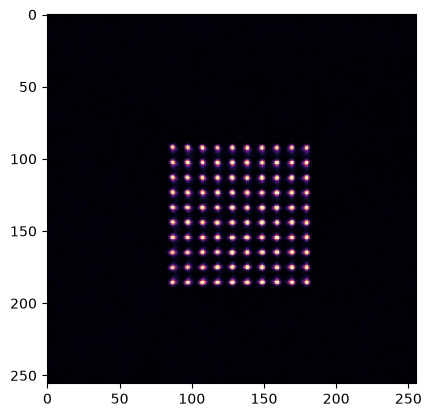

In [70]:
imgs_mean = np.mean(imgs, axis=0)
bgs_mean = np.mean(bgs, axis=0)
imgs_sub = imgs_mean - bgs_mean
imgs_filtered = an.morphological_tophat_high_pass(imgs_sub, feature_size=10)

plt.imshow(imgs_filtered, cmap='magma', vmax=imgs_filtered.max()*0.5)

Looking for trap sites...
100 Atoms Detected.
Trap (0) Loading Probability : 54.00 %
Trap (1) Loading Probability : 58.40 %
Trap (2) Loading Probability : 56.90 %
Trap (3) Loading Probability : 57.10 %
Trap (4) Loading Probability : 54.20 %
Trap (5) Loading Probability : 58.60 %
Trap (6) Loading Probability : 58.20 %
Trap (7) Loading Probability : 53.60 %
Trap (8) Loading Probability : 53.90 %
Trap (9) Loading Probability : 53.80 %
Trap (10) Loading Probability : 57.10 %
Trap (11) Loading Probability : 56.60 %
Trap (12) Loading Probability : 56.60 %
Trap (13) Loading Probability : 55.90 %
Trap (14) Loading Probability : 56.20 %
Trap (15) Loading Probability : 54.50 %
Trap (16) Loading Probability : 54.70 %
Trap (17) Loading Probability : 56.80 %
Trap (18) Loading Probability : 53.90 %
Trap (19) Loading Probability : 54.50 %
Trap (20) Loading Probability : 55.10 %
Trap (21) Loading Probability : 56.00 %
Trap (22) Loading Probability : 56.10 %
Trap (23) Loading Probability : 54.30 %
Trap

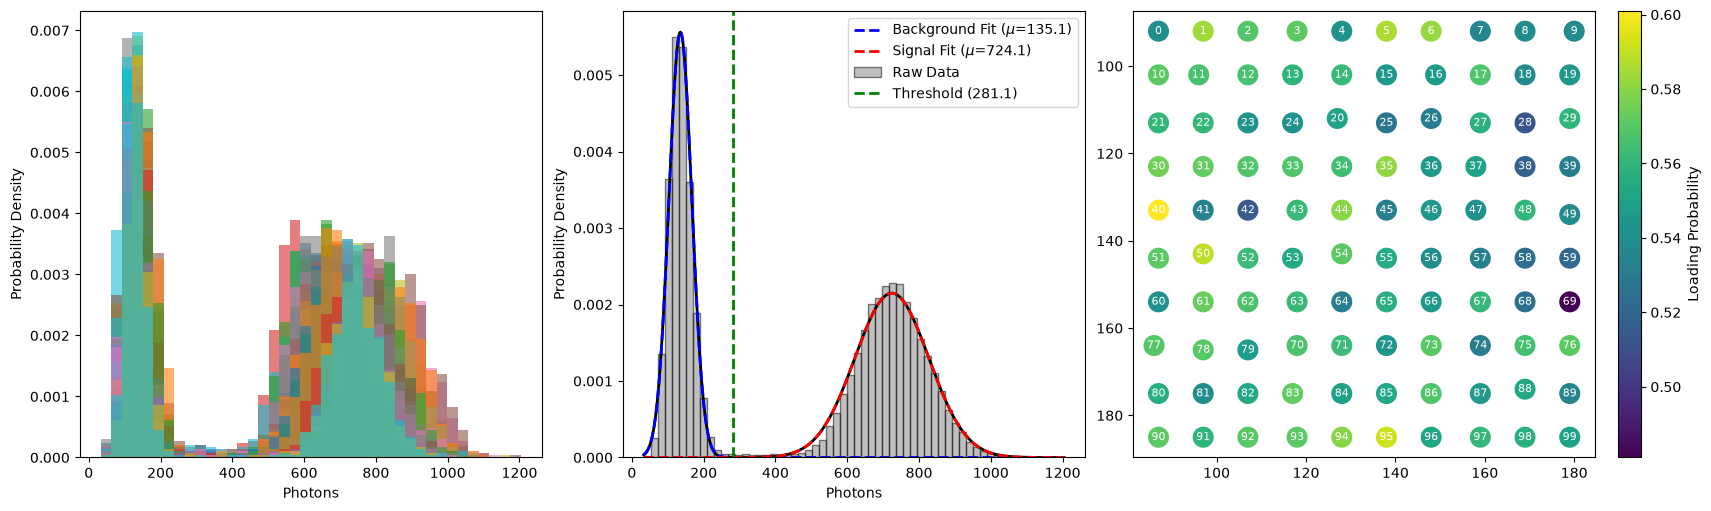

In [58]:
feature_size = 10
imgs_n_mean = np.mean(imgs, axis=0) - np.mean(bgs, axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions, detection_threshold = detect_trap_sites_general(imgs_n_mean_filtered, 10*10, detection_step=100)

imgs_n_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs]
output = get_array_loading_statistics(imgs_n_filtered, grid_positions, threshold=400, window_size=5, binning=60, show_histogram=True, threshold_detection=True, verbose=True)

Looking for trap sites...
72 Atoms Detected.
Trap (0) Loading Probability : 92.00 %
Trap (1) Loading Probability : 86.00 %
Trap (2) Loading Probability : 88.00 %
Trap (3) Loading Probability : 92.00 %
Trap (4) Loading Probability : 81.00 %
Trap (5) Loading Probability : 87.00 %
Trap (6) Loading Probability : 83.00 %
Trap (7) Loading Probability : 89.00 %
Trap (8) Loading Probability : 94.00 %
Trap (9) Loading Probability : 85.00 %
Trap (10) Loading Probability : 85.00 %
Trap (11) Loading Probability : 82.00 %
Trap (12) Loading Probability : 90.00 %
Trap (13) Loading Probability : 89.00 %
Trap (14) Loading Probability : 93.00 %
Trap (15) Loading Probability : 84.00 %
Trap (16) Loading Probability : 89.00 %
Trap (17) Loading Probability : 88.00 %
Trap (18) Loading Probability : 91.00 %
Trap (19) Loading Probability : 88.00 %
Trap (20) Loading Probability : 90.00 %
Trap (21) Loading Probability : 88.00 %
Trap (22) Loading Probability : 81.00 %
Trap (23) Loading Probability : 92.00 %
Trap 

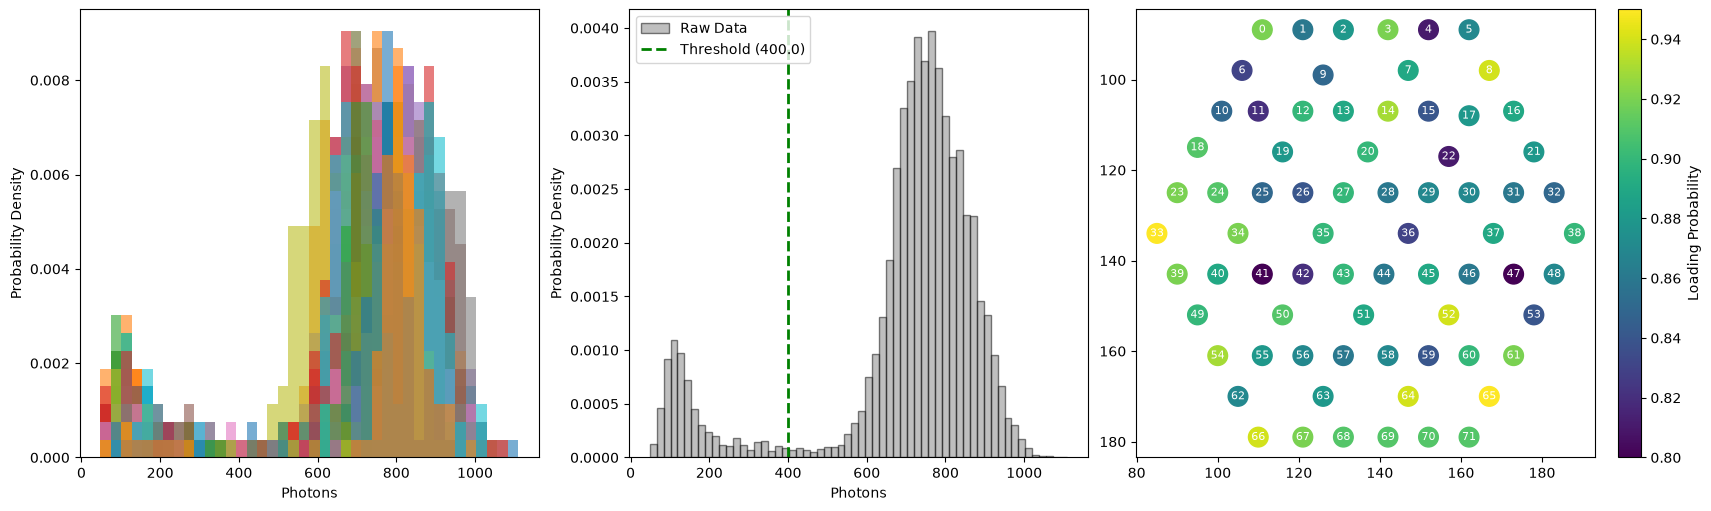

In [49]:
dataset_dir = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\21Aug26\\rearrangement_12x12square_72kagome"
pickle_file = os.path.join(dataset_dir, "timing_and_images.pkl")

# Extract the relevant data from the pickle file
with open(pickle_file, "rb") as f:
    data = pickle.load(f)
    imgs0 = data["imgs0"]
    imgs1 = data["imgs1"]
    imgs2 = data["imgs2"]

feature_size = 10
imgs_n_mean = np.mean(imgs1, axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)
grid_positions, detection_threshold = detect_trap_sites_general(imgs_n_mean_filtered, 72, detection_step=100)

imgs_n_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
output = get_array_loading_statistics(imgs_n_filtered, grid_positions, threshold=400, window_size=5, binning=60, show_histogram=True, threshold_detection=False, verbose=True)

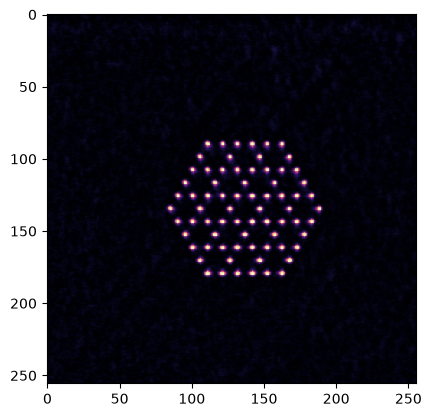

In [25]:
plt.imshow(imgs_n_mean_filtered, cmap='magma', vmax=imgs_n_mean_filtered.max()*0.5)

In [ ]:
import os

DATA_DIR = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\"

def load_data(date, dataset):
    dataset_dir = os.path.join(DATA_DIR, date, dataset)
    dataset_files = os.listdir(dataset_dir)
    pickle_files = 


load_data("21Aug26", "rearrangement_12x12square_72kagome")

'C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\21Aug26\\rearrangement_12x12square_72kagome'

In [24]:
DATA_DIR = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\"

import pickle
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Any
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import tifffile

@dataclass
class ExperimentalData:
    """A structured container for experimental dataset contents."""
    info: str = ""
    pickles: Dict[str, Any] = field(default_factory=dict)
    images: Dict[str, List[np.ndarray]] = field(default_factory=dict)

def _get_path_from_date(date_folder: str) -> Path:
    """
    Helper function to convert a date string like '22Aug26' into the 
    new nested directory structure: DATA_DIR / '2026' / 'Aug' / '22Aug26'
    """
    try:
        # Parse the string to extract year and month
        dt = datetime.strptime(date_folder, "%d%b%y")
        year_str = dt.strftime("%Y")
        month_str = dt.strftime("%b")
        return Path(DATA_DIR) / year_str / month_str / date_folder
    except ValueError:
        raise ValueError(f"Date folder '{date_folder}' does not match format 'DDMonYY' (e.g., '22Aug26')")


def list_datasets(date_folder: str) -> List[str]:
    """
    Lists and returns all dataset directories within a specific date folder.
    Automatically resolves the Year/Month/Date path structure.
    """
    date_path = _get_path_from_date(date_folder)
    
    if not date_path.exists() or not date_path.is_dir():
        print(f"Error: Date folder not found at {date_path}")
        return []
        
    datasets = [item.name for item in date_path.iterdir() if item.is_dir()]
    
    print(f"Datasets found in {date_path}:")
    if not datasets:
        print("  (No dataset folders found)")
    else:
        for ds in sorted(datasets):
            print(f"  - {ds}/")
            
    return sorted(datasets)


def load_dataset(date_folder: str, dataset_title: str) -> ExperimentalData:
    """
    Extracts text, pickle files, and .tif images from a specific dataset directory.
    Automatically resolves the Year/Month/Date path structure.
    """
    dataset_path = _get_path_from_date(date_folder) / dataset_title
    
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset directory not found: {dataset_path}")
        
    # --- Print directory contents ---
    print(f"Loading dataset: {dataset_title}")
            
    data = ExperimentalData()
    
    # 1. Extract and print the contextual .txt information
    txt_files = list(dataset_path.glob("*.txt"))
    if txt_files:
        with open(txt_files[0], 'r', encoding='utf-8') as f:
            data.info = f.read()
            print("\n--- Experimental Info ---\n")
            print(data.info.strip())
            print("\n" + "-" * 40)

    dirs = []
    files = []
    for item in dataset_path.iterdir():
        if item.is_dir():
            dirs.append(item.name)
        else:
            files.append(item.name)

    print("Contents:")
    if dirs:
        print("  Subdirectories:")
        for d in sorted(dirs):
            print(f"    - {d}/")
    if files:
        print("  Files:")
        for f in sorted(files):
            print(f"    - {f}")
    print("-" * 40)
    
    # 2. Extract data from all .pkl files (and .pickle for backwards compatibility)
    pickle_files = list(dataset_path.glob("*.pkl")) + list(dataset_path.glob("*.pickle"))
    for p_file in pickle_files:
        with open(p_file, 'rb') as f:
            data.pickles[p_file.name] = pickle.load(f)
            
    # 3. Extract .tif images from any subdirectories using tifffile
    for item in dataset_path.iterdir():
        if item.is_dir():
            tif_files = sorted(list(item.glob("*.tif")) + list(item.glob("*.tiff")))
            
            if tif_files:
                image_list = []
                for tif_file in tif_files:
                    img_array = tifffile.imread(str(tif_file))
                    image_list.append(img_array)
                    
                data.images[item.name] = image_list
                
    return data


def save_dataset(
    dataset_title: str, 
    context_info: str = "", 
    pickles: Dict[str, Any] = None, 
    images: Dict[str, List[np.ndarray]] = None
) -> None:
    """
    Saves text, pickle variables, and image arrays into a new dataset directory.
    Automatically generates the Year/Month/Date path structure for today.
    Prevents overwriting by appending a suffix to the title if needed.
    """
    if pickles is None:
        pickles = {}
    if images is None:
        images = {}
        
    now = datetime.now()
    year_str = now.strftime("%Y")
    month_str = now.strftime("%b")
    date_folder = now.strftime("%d%b%y")
    
    # Establish the base date directory, e.g. DATA_DIR/2026/Aug/22Aug26
    date_path = Path(DATA_DIR) / year_str / month_str / date_folder
    
    # Check for existing dataset and append suffix if necessary
    original_title = dataset_title
    counter = 1
    dataset_path = date_path / dataset_title
    
    while dataset_path.exists():
        dataset_title = f"{original_title}_{counter}"
        dataset_path = date_path / dataset_title
        counter += 1
        
    # This creates the year, month, date, and dataset folders all at once if they don't exist
    dataset_path.mkdir(parents=True, exist_ok=True)
    
    if counter > 1:
        print(f"Dataset '{original_title}' already exists. Renaming to '{dataset_title}'.")
    
    # 1. Write the experiment_info.txt
    info_file = dataset_path / "experiment_info.txt"
    with open(info_file, "w", encoding='utf-8') as f:
        f.write(f"Dataset Title: {dataset_title}\n")
        f.write(f"Date: {now.strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(context_info)
        
    # 2. Save pickle variables with forced .pkl extension
    for filename, variable in pickles.items():
        if filename.endswith(".pickle"):
            filename = filename[:-7] + ".pkl"
        elif not filename.endswith(".pkl"):
            filename += ".pkl"
            
        with open(dataset_path / filename, 'wb') as f:
            pickle.dump(variable, f)
            
    # 3. Save image arrays using tifffile
    for folder_name, img_list in images.items():
        img_folder = dataset_path / folder_name
        img_folder.mkdir(exist_ok=True)
        
        for i, img_array in enumerate(img_list):
            img_path = img_folder / f"image_{i:03d}.tif"
            tifffile.imwrite(str(img_path), img_array)
            
    print(f"Successfully saved to {dataset_path}")

In [19]:
# Load the data
dataset = load_dataset(
    date_folder="21Aug26", 
    dataset_title="rearrangement_12x12square_72kagome"
)

Loading dataset: rearrangement_12x12square_72kagome

--- Experimental Info ---

Dataset Title: rearrangement_12x12square_72kagome
Date: 2026-08-21 18:14:05

    50 ms time slot given for rearrangement.
    Rearrangement parameters: d0 = 0.5, threshold = 2322.5737 photons, profile = linear, window_size = 5, feature_size = 10.
    Occupancy extraction using the PSF method. Rearrangement from 12x12 square array to 72 site Kagome lattice. Using 50 ms images for final two, 5 ms images for initial.

----------------------------------------
Contents:
  Subdirectories:
    - 0_images/
    - 1_images/
    - 2_images/
  Files:
    - experiment_info.txt
    - timing_and_images.pkl
----------------------------------------


In [25]:
# Create some dummy data
my_context = """
    These runs were done at a trap depth of 2 mK with 50ms hold time. Here's a bunch of additional information.
    Oh and another line to see how the formatting works. etc. etc.
"""
my_pickles = {
    "run_parameters.pickle": {"trap_depth": 2.0, "hold_time": 50},
    "processed_data": [1, 2, 3, 4, 5]  # The function will auto-append .pickle
}
my_images = {
    "camera_1_views": [np.random.rand(100, 100), np.random.rand(100, 100)],
    "camera_2_views": [np.random.rand(100, 100)]
}
# Save it all
save_dataset(
    dataset_title="test_dataset",
    context_info=my_context,
    pickles=my_pickles,
    images=my_images
)

Dataset 'test_dataset' already exists. Renaming to 'test_dataset_5'.
Successfully saved to C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\22Aug26\test_dataset_5


In [26]:
list_datasets("22Aug26");

Datasets found in C:\Users\tweez\Box\Working folder\caftweezers\Data\2026\Aug\22Aug26:
  - test_dataset/
  - test_dataset_1/
  - test_dataset_2/
  - test_dataset_3/
  - test_dataset_4/
  - test_dataset_5/


In [27]:
dataset = load_dataset("22Aug26", "test_dataset_5")

Loading dataset: test_dataset_5

--- Experimental Info ---

Dataset Title: test_dataset_5
Date: 2026-08-22 15:11:58

    These runs were done at a trap depth of 2 mK with 50ms hold time. Here's a bunch of additional information.
    Oh and another line to see how the formatting works. etc. etc.

----------------------------------------
Contents:
  Subdirectories:
    - camera_1_views/
    - camera_2_views/
  Files:
    - experiment_info.txt
    - processed_data.pkl
    - run_parameters.pkl
----------------------------------------


In [65]:
processed_data = dataset.pickles.get("processed_data.pkl")
run_parameters = dataset.pickles.get("run_parameters.pkl")

In [66]:
processed_data

[1, 2, 3, 4, 5]